# CICIDS2017 — RF + XGBoost Ensemble Training
### 46 features, 5 classes: Normal Traffic, DoS, DDoS, Brute Force, Port Scan
Run on Kaggle with `cicids2017_preprocessed.csv` uploaded as a dataset.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Paths — update if running locally
DATA_PATH   = r'D:\Academic\ML\ModelTraining\Preprocessing\cicids2017_preprocessed.csv'
MODEL_OUT   = r'D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl'
SCALER_OUT  = r'D:\Academic\ML\ModelTraining\newOutput\scaler.pkl'
ENCODER_OUT = r'D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl'

RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Attack Type'].value_counts())
print(f'\nFeatures: {df.shape[1] - 1}')

Shape: (2515963, 47)

Class distribution:
Attack Type
Normal Traffic    2094458
DoS                193647
DDoS               128014
Port Scan           90694
Brute Force          9150
Name: count, dtype: int64

Features: 46


## 2. Feature / Label Split

In [3]:
feature_cols = [c for c in df.columns if c != 'Attack Type']
print(f'Feature columns ({len(feature_cols)}):')
for i, c in enumerate(feature_cols):
    print(f'  {i+1:2d}. {c}')

X = df[feature_cols].values
y_raw = df['Attack Type'].values

Feature columns (46):
   1. Destination Port
   2. Flow Duration
   3. Total Fwd Packets
   4. Total Backward Packets
   5. Total Length of Fwd Packets
   6. Total Length of Bwd Packets
   7. Fwd Packet Length Max
   8. Fwd Packet Length Min
   9. Fwd Packet Length Mean
  10. Fwd Packet Length Std
  11. Bwd Packet Length Max
  12. Bwd Packet Length Min
  13. Bwd Packet Length Mean
  14. Bwd Packet Length Std
  15. Flow Bytes/s
  16. Flow Packets/s
  17. Flow IAT Mean
  18. Flow IAT Std
  19. Flow IAT Max
  20. Flow IAT Min
  21. Fwd IAT Mean
  22. Fwd IAT Std
  23. Fwd IAT Min
  24. Bwd IAT Total
  25. Bwd IAT Mean
  26. Bwd IAT Max
  27. Bwd IAT Min
  28. Fwd Header Length
  29. Bwd Header Length
  30. Bwd Packets/s
  31. Min Packet Length
  32. Max Packet Length
  33. Packet Length Mean
  34. Packet Length Std
  35. Packet Length Variance
  36. FIN Flag Count
  37. PSH Flag Count
  38. ACK Flag Count
  39. Init_Win_bytes_forward
  40. Init_Win_bytes_backward
  41. act_data_pkt_fwd
  

## 3. Label Encoding

In [4]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'Classes: {list(le.classes_)}')
print(f'Encoded: {list(range(len(le.classes_)))}')

joblib.dump(le, ENCODER_OUT)
print(f'Saved: {ENCODER_OUT}')

Classes: ['Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scan']
Encoded: [0, 1, 2, 3, 4]
Saved: D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl


## 4. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Verify stratification
unique, counts = np.unique(y_train, return_counts=True)
print('\nTrain class distribution:')
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls}: {cnt:,}')

Train: (2012770, 46), Test: (503193, 46)

Train class distribution:
  Brute Force: 7,320
  DDoS: 102,411
  DoS: 154,918
  Normal Traffic: 1,675,566
  Port Scan: 72,555


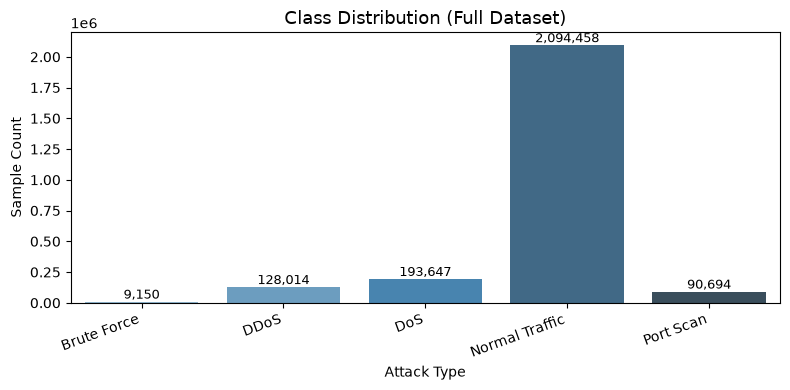

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
class_counts = pd.Series(
    [(y_train == i).sum() + (y_test == i).sum() for i in range(len(le.classes_))],
    index=le.classes_
)
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Class Distribution (Full Dataset)', fontsize=13)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Sample Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Scaling

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_OUT)
print(f'Saved: {SCALER_OUT}')

Saved: D:\Academic\ML\ModelTraining\newOutput\scaler.pkl


## 6. Compute Sample Weights
Handles class imbalance for both RF and XGBoost.

In [8]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(f'Sample weight range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')

# Show effective weight per class
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    print(f'  {cls_name}: weight = {sample_weights[mask].mean():.4f}')

Sample weight range: 0.2402 — 54.9937
  Brute Force: weight = 54.9937
  DDoS: weight = 3.9308
  DoS: weight = 2.5985
  Normal Traffic: weight = 0.2402
  Port Scan: weight = 5.5483


## 7. Train Random Forest

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced_subsample',   # RF handles imbalance natively via class_weight
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train)
print('RF training complete.')

rf_train_acc = rf.score(X_train_scaled, y_train)
rf_test_acc  = rf.score(X_test_scaled,  y_test)
print(f'RF Train Accuracy: {rf_train_acc:.4f}')
print(f'RF Test  Accuracy: {rf_test_acc:.4f}')

RF training complete.
RF Train Accuracy: 0.9998
RF Test  Accuracy: 0.9995


## 8. Train XGBoost
Trained separately with sample_weight — fixes the VotingClassifier bug
where sample weights are not routed to internal estimators.

In [10]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',        # use 'hist' — gpu_hist not supported on Kaggle free tier
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=1
)
# Pass sample_weight directly — this is the fix for the imbalance bug
xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights,
        eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
        verbose=20)
print('XGBoost training complete.')

xgb_train_acc = xgb.score(X_train_scaled, y_train)
xgb_test_acc  = xgb.score(X_test_scaled,  y_test)
print(f'XGB Train Accuracy: {xgb_train_acc:.4f}')
print(f'XGB Test  Accuracy: {xgb_test_acc:.4f}')

[0]	validation_0-mlogloss:1.39625	validation_1-mlogloss:1.39620
[20]	validation_0-mlogloss:0.17431	validation_1-mlogloss:0.17437
[40]	validation_0-mlogloss:0.03137	validation_1-mlogloss:0.03148
[60]	validation_0-mlogloss:0.00904	validation_1-mlogloss:0.00916
[80]	validation_0-mlogloss:0.00472	validation_1-mlogloss:0.00484
[100]	validation_0-mlogloss:0.00309	validation_1-mlogloss:0.00323
[120]	validation_0-mlogloss:0.00246	validation_1-mlogloss:0.00260
[140]	validation_0-mlogloss:0.00215	validation_1-mlogloss:0.00230
[160]	validation_0-mlogloss:0.00198	validation_1-mlogloss:0.00215
[180]	validation_0-mlogloss:0.00187	validation_1-mlogloss:0.00205
[200]	validation_0-mlogloss:0.00178	validation_1-mlogloss:0.00199
[220]	validation_0-mlogloss:0.00173	validation_1-mlogloss:0.00195
[240]	validation_0-mlogloss:0.00169	validation_1-mlogloss:0.00193
[260]	validation_0-mlogloss:0.00166	validation_1-mlogloss:0.00192
[280]	validation_0-mlogloss:0.00163	validation_1-mlogloss:0.00191
[299]	validation

## 9. Build Soft-Voting Ensemble
Uses pre-fitted estimators — VotingClassifier is set to use them as-is.

In [11]:
from sklearn.preprocessing import LabelEncoder as SklearnLE
from sklearn.utils.multiclass import unique_labels

# Manually construct a minimal internal LabelEncoder that maps 0-4 to 0-4
internal_le = SklearnLE()
internal_le.fit(np.array(list(range(len(le.classes_)))))

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)
ensemble.estimators_ = [rf, xgb]
ensemble.le_ = internal_le
ensemble.classes_ = np.array(list(range(len(le.classes_))))
ensemble.named_estimators_ = {'rf': rf, 'xgb': xgb}

ensemble_test_acc = ensemble.score(X_test_scaled, y_test)
print(f'Ensemble Test Accuracy: {ensemble_test_acc:.4f}')

joblib.dump(ensemble, MODEL_OUT)
print(f'Saved: {MODEL_OUT}')

Ensemble Test Accuracy: 0.9997
Saved: D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl


## 10. Classification Report

In [12]:
y_pred = ensemble.predict(X_test_scaled)
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

                precision    recall  f1-score   support

   Brute Force       1.00      1.00      1.00      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      1.00      1.00     38729
Normal Traffic       1.00      1.00      1.00    418892
     Port Scan       1.00      1.00      1.00     18139

      accuracy                           1.00    503193
     macro avg       1.00      1.00      1.00    503193
  weighted avg       1.00      1.00      1.00    503193



## 11. Confusion Matrix

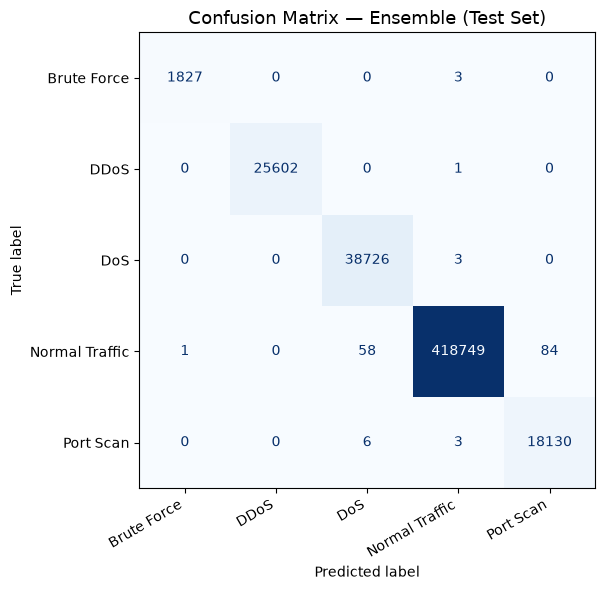

In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Ensemble (Test Set)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\confusion_matrix.png', bbox_inches='tight')
plt.show()

## 12. Per-Model Comparison

In [14]:
from sklearn.metrics import f1_score

rf_pred  = rf.predict(X_test_scaled)
xgb_pred = xgb.predict(X_test_scaled)
ens_pred = y_pred

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Ensemble'],
    'Test Accuracy': [
        rf.score(X_test_scaled, y_test),
        xgb.score(X_test_scaled, y_test),
        ensemble.score(X_test_scaled, y_test)
    ],
    'Macro F1': [
        f1_score(y_test, rf_pred,  average='macro'),
        f1_score(y_test, xgb_pred, average='macro'),
        f1_score(y_test, ens_pred, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, rf_pred,  average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted'),
        f1_score(y_test, ens_pred, average='weighted')
    ]
})
print(results.to_string(index=False))

        Model  Test Accuracy  Macro F1  Weighted F1
Random Forest       0.999549  0.998782     0.999549
      XGBoost       0.999642  0.998991     0.999643
     Ensemble       0.999684  0.999056     0.999684


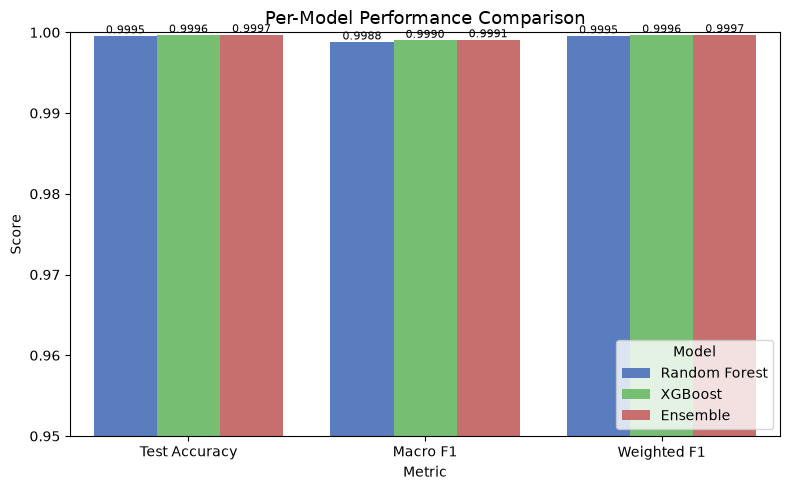

In [15]:
metrics_df = results.melt(id_vars='Model', value_vars=['Test Accuracy', 'Macro F1', 'Weighted F1'],
                           var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model',
            palette=['#4878CF', '#6ACC65', '#D65F5F'], ax=ax)
ax.set_title('Per-Model Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.95, 1.0)
ax.legend(title='Model', loc='lower right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

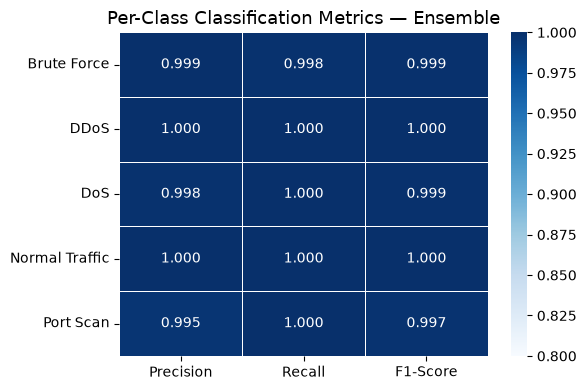

In [16]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.loc[le.classes_, ['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(report_df.astype(float), annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0.8, vmax=1.0)
ax.set_title('Per-Class Classification Metrics — Ensemble', fontsize=13)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\classification_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Feature Importance (RF)

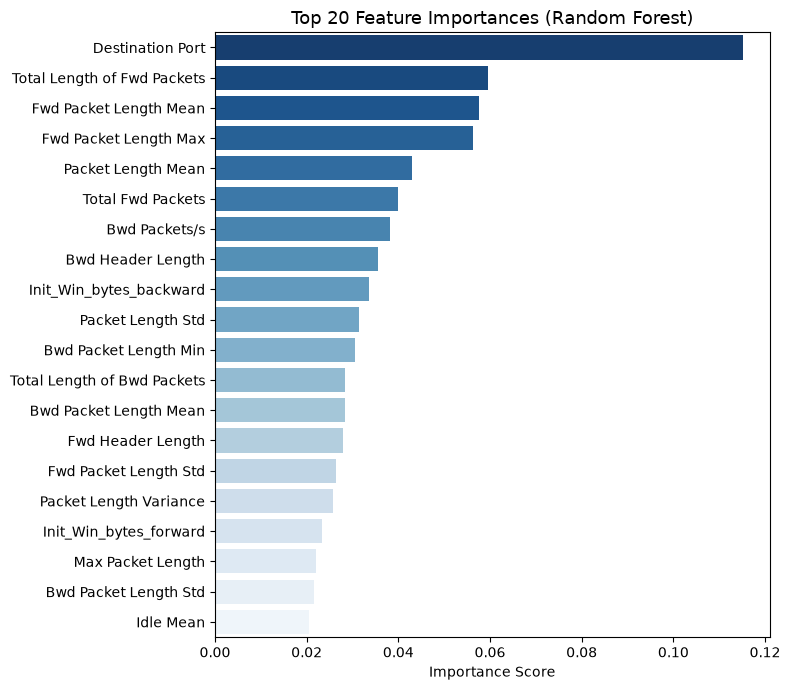

In [17]:
top_n = 20
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r', ax=ax)
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\feature_importance_top20.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Verify Saved Artifacts

In [26]:
# Reload and do a quick sanity check
loaded_model   = joblib.load(MODEL_OUT)
loaded_scaler  = joblib.load(SCALER_OUT)
loaded_encoder = joblib.load(ENCODER_OUT)

# Single sample prediction
sample_raw     = X_test[0:1]
sample_scaled  = loaded_scaler.transform(sample_raw)
pred_encoded   = loaded_model.predict(sample_scaled)
pred_label     = loaded_encoder.inverse_transform(pred_encoded)
pred_proba     = loaded_model.predict_proba(sample_scaled)

print(f'Sample prediction: {pred_label[0]}')
print(f'True label:        {loaded_encoder.inverse_transform([y_test[0]])[0]}')
print(f'\nClass probabilities:')
for cls, prob in zip(loaded_encoder.classes_, pred_proba[0]):
    print(f'  {cls}: {prob:.4f}')

Sample prediction: Normal Traffic
True label:        Normal Traffic

Class probabilities:
  Brute Force: 0.0000
  DDoS: 0.0000
  DoS: 0.0000
  Normal Traffic: 1.0000
  Port Scan: 0.0000
